In [14]:
#Importing required libraries

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


import tensorflow as tf


import numpy as np #
import pandas as pd 
from tqdm import tqdm
from keras import Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam, SGD
from keras.callbacks import ReduceLROnPlateau
from keras.layers import Flatten,Dense,BatchNormalization,Activation,Dropout
from keras.layers import Lambda, Input, GlobalAveragePooling2D,BatchNormalization
from keras.utils import to_categorical
# from keras import regularizers
from tensorflow.keras.models import Model
from keras.preprocessing.image import load_img

In [28]:
#reading labels csv file

labels = pd.read_csv('./DogVision/labels.csv')
labels.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [29]:
#describe
labels.describe()

,id,breed
count,10222,10222
unique,10222,120
top,000bec180eb18c7604dcecc8fe0dba07,scottish_deerhound
freq,1,126


In [31]:
# #total unique breeds

# labels['breed'].nunique()

**Observation:**
1. We have total 120 unique breeds
2. We have atleast 60 images per category of breed
3. Google recommends at least 10 images per class to get a better model
4. More sample available ----- > More efficeint the model will be

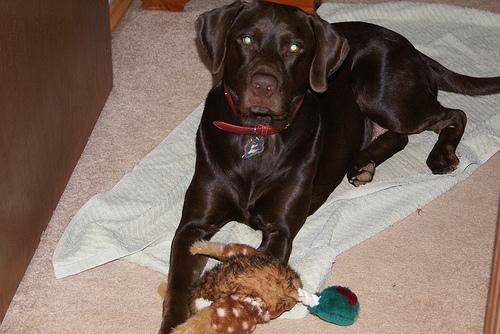

In [32]:
# Lets check one image
from IPython.display import display, Image
Image("./DogVision/train/43572ba7edf772a95f539e57afd9eb43.jpg")

In [33]:
import os
if len(os.listdir('./DogVision/train/')) == len(labels['id']):
    print('Number of file matches number of actual images!')
else:
    print('Number of file doesnot matches number of actual images!!')

Number of file matches number of actual images!


In [34]:

#Create list of alphabetically sorted labels.
classes = sorted(list(set(labels['breed'])))
n_classes = len(classes)
print('Total unique breed {}'.format(n_classes))

#Map each label string to an integer label.
class_to_num = dict(zip(classes, range(n_classes)))
class_to_num


Total unique breed 120


{'affenpinscher': 0,
 'afghan_hound': 1,
 'african_hunting_dog': 2,
 'airedale': 3,
 'american_staffordshire_terrier': 4,
 'appenzeller': 5,
 'australian_terrier': 6,
 'basenji': 7,
 'basset': 8,
 'beagle': 9,
 'bedlington_terrier': 10,
 'bernese_mountain_dog': 11,
 'black-and-tan_coonhound': 12,
 'blenheim_spaniel': 13,
 'bloodhound': 14,
 'bluetick': 15,
 'border_collie': 16,
 'border_terrier': 17,
 'borzoi': 18,
 'boston_bull': 19,
 'bouvier_des_flandres': 20,
 'boxer': 21,
 'brabancon_griffon': 22,
 'briard': 23,
 'brittany_spaniel': 24,
 'bull_mastiff': 25,
 'cairn': 26,
 'cardigan': 27,
 'chesapeake_bay_retriever': 28,
 'chihuahua': 29,
 'chow': 30,
 'clumber': 31,
 'cocker_spaniel': 32,
 'collie': 33,
 'curly-coated_retriever': 34,
 'dandie_dinmont': 35,
 'dhole': 36,
 'dingo': 37,
 'doberman': 38,
 'english_foxhound': 39,
 'english_setter': 40,
 'english_springer': 41,
 'entlebucher': 42,
 'eskimo_dog': 43,
 'flat-coated_retriever': 44,
 'french_bulldog': 45,
 'german_shepherd'

**One-hot Encoding:**
Since the output of our predictor for each input is a vector of probabilities for each class we must convert out label dataset to be the same format. That is for each input a row vector of length num_classes with a 1 at the index of the label and 0's everywhere else.

In [12]:

input_shape = (331,331,3)


def images_to_array(directory, label_dataframe, target_size = input_shape):
    
    image_labels = label_dataframe['breed']
    images = np.zeros([len(label_dataframe), target_size[0], target_size[1], target_size[2]],dtype=np.uint8) #as we have huge data and limited ram memory. uint8 takes less memory
    y = np.zeros([len(label_dataframe),1],dtype = np.uint8)
    
    for ix, image_name in enumerate(tqdm(label_dataframe['id'].values)):
        img_dir = os.path.join(directory, image_name + '.jpg')
        img = load_img(img_dir, target_size = target_size)
#         img = np.expand_dims(img, axis=0)
#         img = processed_image_resnet(img)
#         img = img/255
        images[ix]=img
#         images[ix] = img_to_array(img)
        del img
        
        dog_breed = image_labels[ix]
        y[ix] = class_to_num[dog_breed]
    
    y = to_categorical(y)
    
    return images,y

In [73]:
X,y = images_to_array('./DogVision/train', labels[:])

NameError: name 'images_to_array' is not defined

In [14]:
y[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32)

In [16]:
## Another way to create one hot encoded vectors
# dummy = pd.get_dummies(df_50['breed'])

# classes = dummy.columns 
# print('we have total {} number of unique dog breeds'.format(len(classes)))

#convert this into np.array

# y = np.array(dummy)
# # we can delete the dummy because we dont need it anymore ----- > We are saving RAM

# del dummy

# y[0:2]

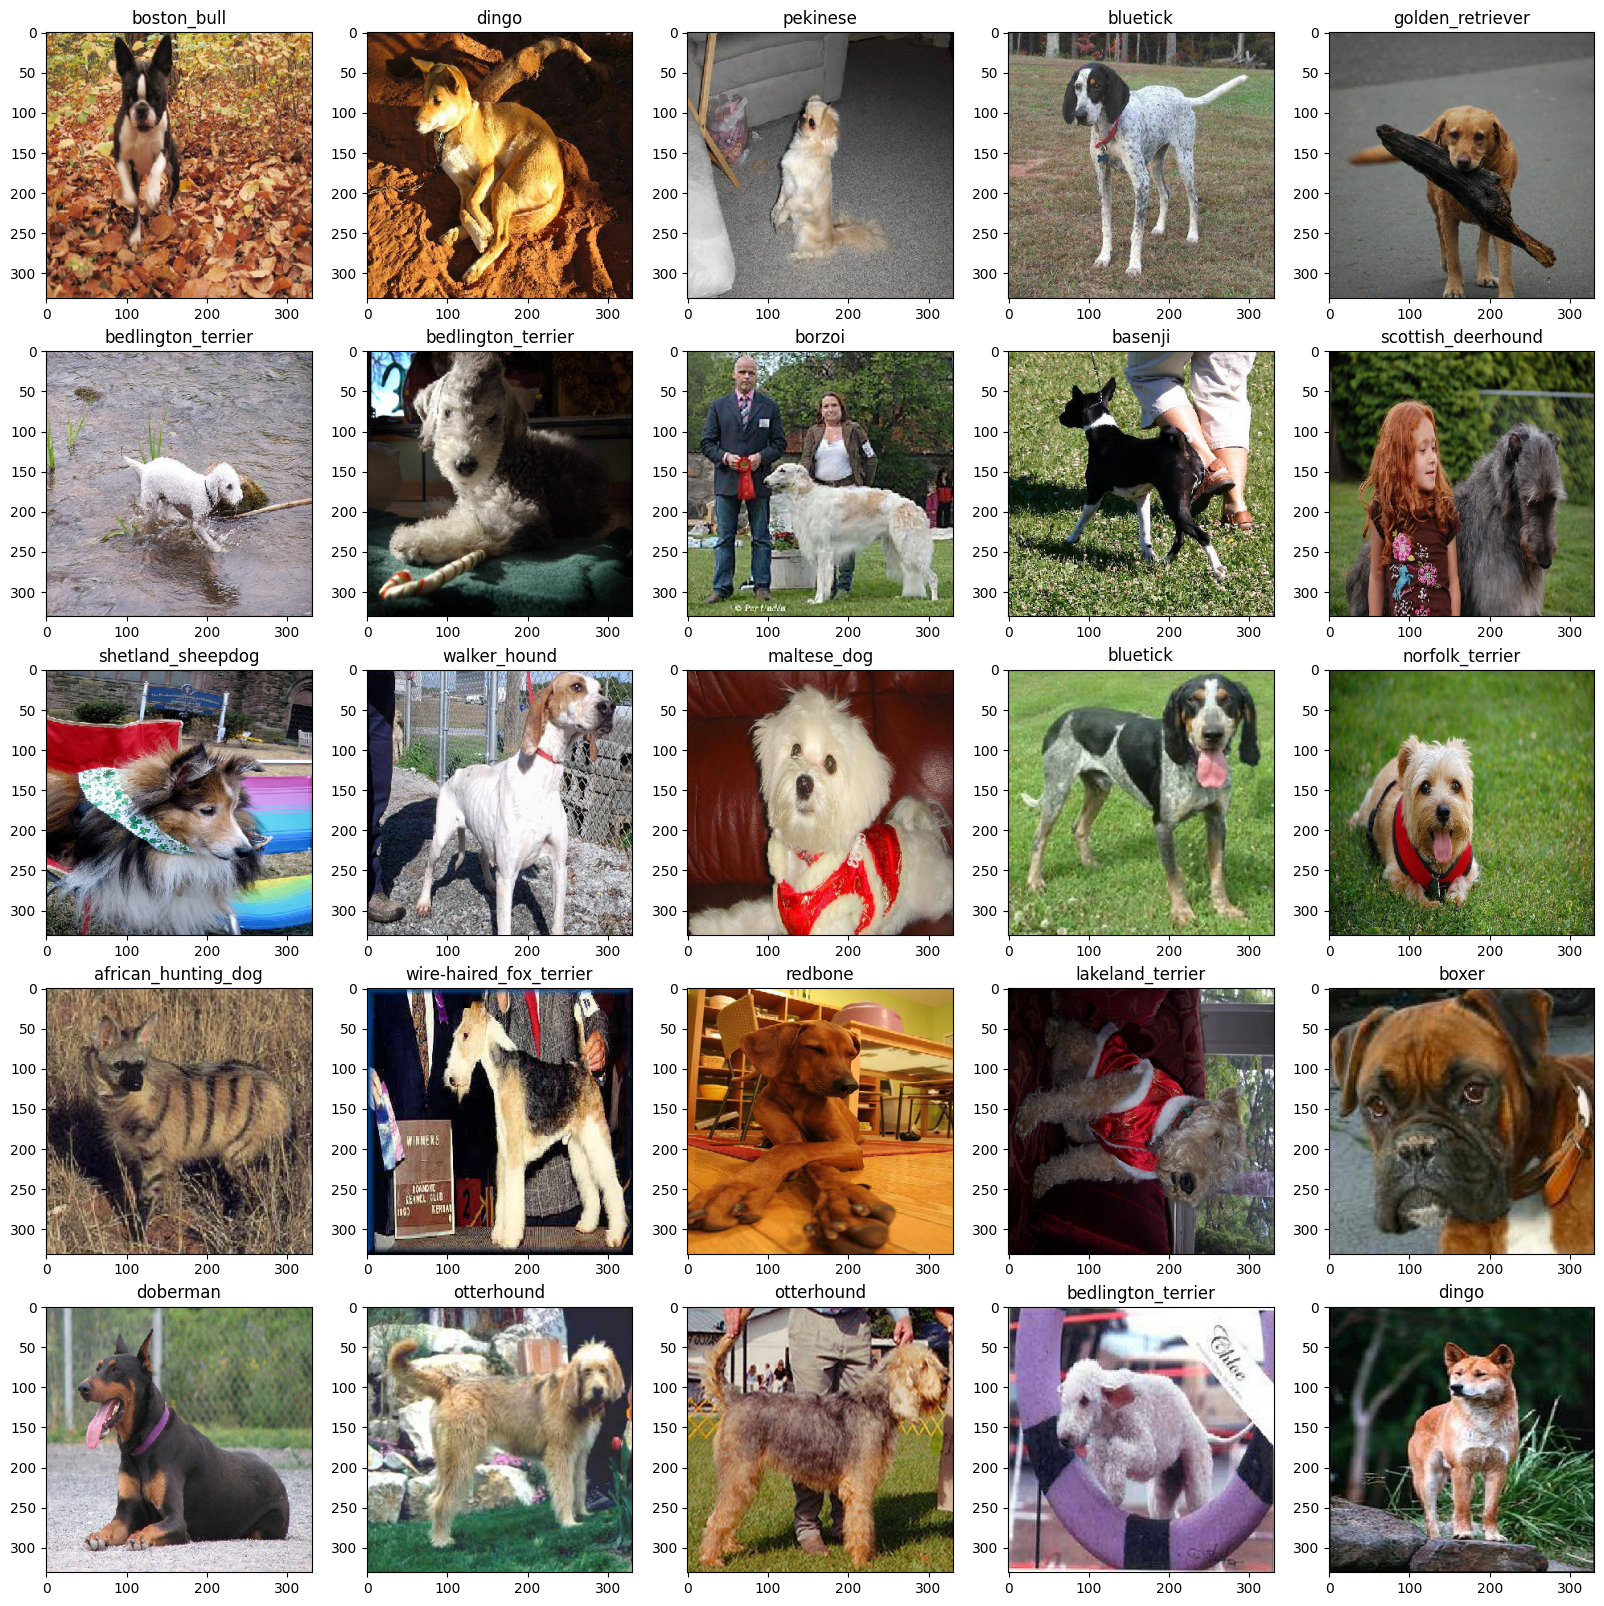

In [17]:
# np.where(y[5]==1)[0][0]

# lets check some dogs and their breeds
n=25

# setup the figure 
plt.figure(figsize=(20,20))

for i in range(n):
#     print(i)
    ax = plt.subplot(5, 5, i+1)
    plt.title(classes[np.where(y[i] ==1)[0][0]])
    plt.imshow(X[i].astype('int32')) # .astype('int32') ---> as imshow() needs integer data to read the image
    

### Creating callbacks:

(things to help our model)

Callbacks are helper functions a model can use during training to do things such as save a models progress, check a models progress or stop training early if a model stops improving.

ReduceLROnPlateau: Reduce learning rate when a metric has stopped improving.

In [45]:
#Learning Rate Annealer
lrr= ReduceLROnPlateau(monitor='val_accuracy', factor=.01, patience=3, min_lr=1e-5,verbose = 1)

#Prepare call backs
EarlyStop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)



In [39]:
# Hyperparameters
batch_size= 128
epochs=50
learn_rate=.001
sgd=SGD(lr=learn_rate,momentum=.9,nesterov=False)
#adam=Adam(lr=learn_rate, beta_1=0.9, beta_2=0.999, epsilon=None,  amsgrad=False)

# Model Building:

* The basic idea here is to extract features from the data set from pretrained models and create a simple deep net by using all those features combined.
* So we will GlobalAveragePooling2D to extract a pooled output from our selected models
* img_size = You can change this shape according to the documentation of the pretrained model
* Keras documentation for all models: https://keras.io/api/applications/



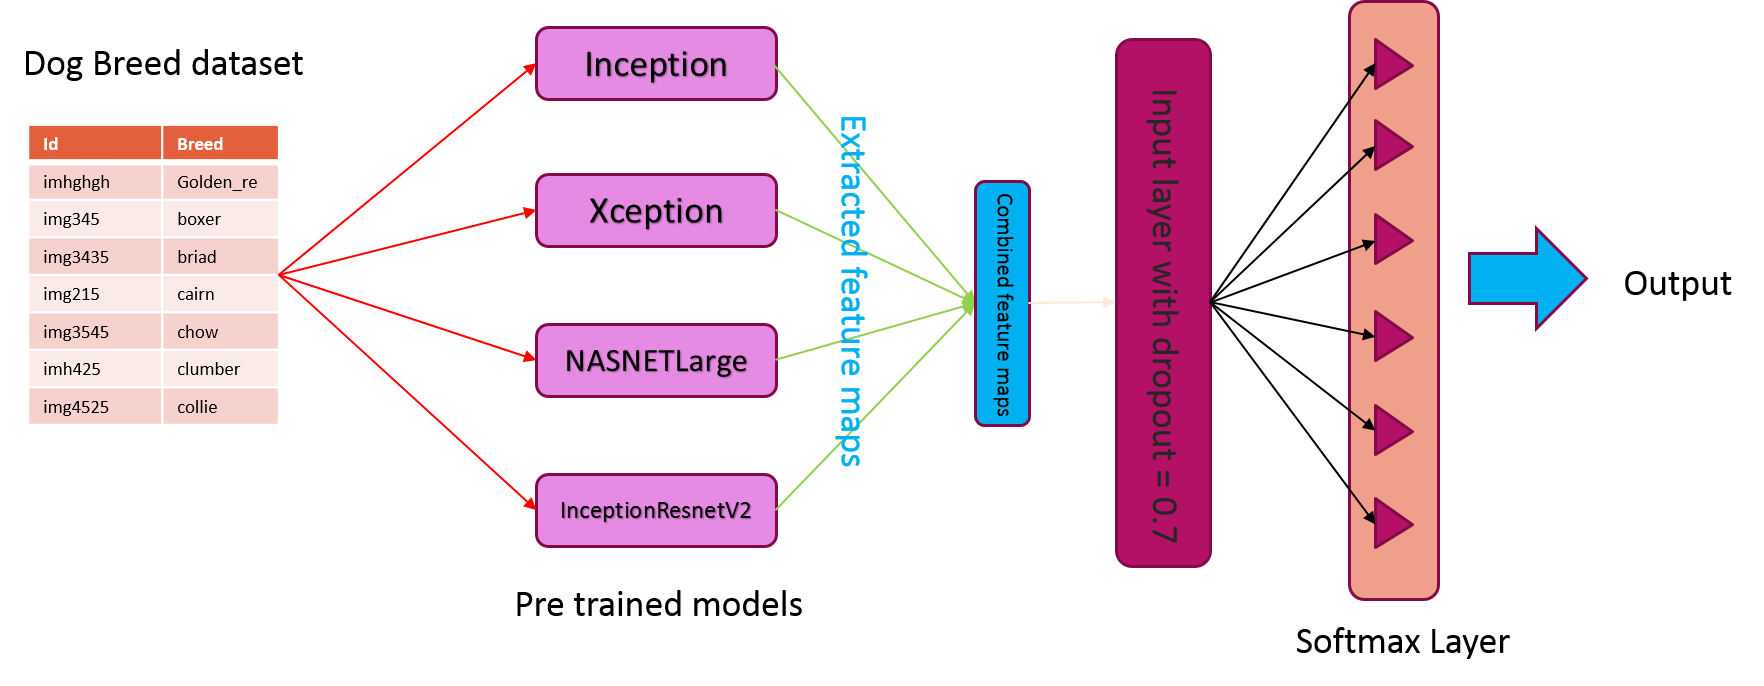

In [15]:
#function to extract features from the dataset by a given pretrained model
img_size = (331,331,3)

def get_features(model_name, model_preprocessor, input_size, data):

    input_layer = Input(input_size)
    preprocessor = Lambda(model_preprocessor)(input_layer)
    base_model = model_name(weights='imagenet', include_top=False,
                            input_shape=input_size)(preprocessor)
    avg = GlobalAveragePooling2D()(base_model)
    feature_extractor = Model(inputs = input_layer, outputs = avg)
    
    #Extract feature.
    feature_maps = feature_extractor.predict(data, verbose=1)
    print('Feature maps shape: ', feature_maps.shape)
    return feature_maps

In [21]:
# Extract features using InceptionV3 
from keras.applications.inception_v3 import InceptionV3, preprocess_input
inception_preprocessor = preprocess_input
inception_features = get_features(InceptionV3,
                                  inception_preprocessor,
                                  img_size, X)

320/320 [==============================] - 786s 2s/step
Feature maps shape:  (10222, 2048)


In [22]:
# Extract features using Xception 
from keras.applications.xception import Xception, preprocess_input
xception_preprocessor = preprocess_input
xception_features = get_features(Xception,
                                 xception_preprocessor,
                                 img_size, X)

320/320 [==============================] - 1398s 4s/step
Feature maps shape:  (10222, 2048)


In [ ]:
# Extract features using InceptionResNetV2 
''' from keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input
inc_resnet_preprocessor = preprocess_input
inc_resnet_features = get_features(InceptionResNetV2,
                                   inc_resnet_preprocessor,
                                   img_size, X)'''

In [ ]:
# Extract features using NASNetLarge 
''' from keras.applications.nasnet import NASNetLarge, preprocess_input
nasnet_preprocessor = preprocess_input
nasnet_features = get_features(NASNetLarge,
                               nasnet_preprocessor,
                               img_size, X)'''

In [23]:
#del X #to free up some ram memory
gc.collect()

NameError: name 'gc' is not defined

In [24]:
#Creating final featuremap by combining all extracted features

final_features = np.concatenate([inception_features,
                                 xception_features,
                                 ], axis=-1) #axis=-1 to concatenate horizontally

print('Final feature maps shape', final_features.shape)

Final feature maps shape (10222, 4096)


In [40]:
#Prepare Deep net

model = Sequential()
# model.add(Dense(1028,input_shape=(final_features.shape[1],)))
model.add(Dropout(0.7,input_shape=(final_features.shape[1],)))
model.add(Dense(n_classes,activation= 'softmax')) #Output Layer

'''model.compile(optimizer=adam,
              loss='categorical_crossentropy',
              metrics=['accuracy'])'''

#Training the model. 
'''history = model.fit(final_features, y,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=0.2,
            callbacks=[lrr,EarlyStop])'''

'history = model.fit(final_features, y,\n            batch_size=batch_size,\n            epochs=epochs,\n            validation_split=0.2,\n            callbacks=[lrr,EarlyStop])'

In [43]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [46]:
history = model.fit(final_features, y,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=0.2,
            callbacks=[lrr,EarlyStop])

Epoch 1/50
64/64 [==============================] - 1s 11ms/step - loss: 0.1139 - accuracy: 0.9678 - val_loss: 0.2094 - val_accuracy: 0.9325 - lr: 0.0010
Epoch 2/50
64/64 [==============================] - 1s 10ms/step - loss: 0.1046 - accuracy: 0.9692 - val_loss: 0.2139 - val_accuracy: 0.9320 - lr: 0.0010
Epoch 3/50
64/64 [==============================] - 1s 9ms/step - loss: 0.0955 - accuracy: 0.9709 - val_loss: 0.2158 - val_accuracy: 0.9242 - lr: 0.0010
Epoch 4/50
63/64 [============================>.] - ETA: 0s - loss: 0.0893 - accuracy: 0.9754
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
64/64 [==============================] - 0s 8ms/step - loss: 0.0896 - accuracy: 0.9753 - val_loss: 0.2220 - val_accuracy: 0.9325 - lr: 0.0010
Epoch 5/50
64/64 [==============================] - 0s 7ms/step - loss: 0.0778 - accuracy: 0.9784 - val_loss: 0.2203 - val_accuracy: 0.9325 - lr: 1.0000e-05
Epoch 6/50
64/64 [==============================] - 1s 10ms/step - lo

In [56]:
import gc
gc.collect()

97483

In [48]:
model.save('DogPred_Model.h5')

c:\Python3.11.3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [58]:
acc,loss=model.evaluate(final_features,y)

320/320 [==============================] - 1s 2ms/step - loss: 0.0983 - accuracy: 0.9733


In [ ]:
#deleting to free up ram memory

del inception_features
del xception_features
del final_features
gc.collect() 

In [ ]:
# sample_df = pd.read_csv('/kaggle/input/dog-breed-identification/sample_submission.csv')

In [ ]:
# sample_df.shape

In [16]:
#Function to read images from test directory
#
import os
import numpy as np
import tqdm as  tqdm
def images_to_array_test(test_path, img_size = (331,331,3)):
    test_filenames = [test_path + fname for fname in os.listdir(test_path)]

    data_size = len(test_filenames)
    images = np.zeros([data_size, img_size[0], img_size[1], 3], dtype=np.uint8)
    
    
    for ix,img_dir in enumerate(test_filenames):
#         img_dir = os.path.join(directory, image_name + '.jpg')
        img = load_img(img_dir, target_size = img_size)
#         img = np.expand_dims(img, axis=0)
#         img = processed_image_resnet(img)
#         img = img/255
        images[ix]=img
#         images[ix] = img_to_array(img)
        del img
    print('Ouptut Data Size: ', images.shape)
    return images
img_size=(331,331,3)
test_data = images_to_array_test('./DogVision/test/', img_size)

Ouptut Data Size:  (10357, 331, 331, 3)


In [70]:
test_data.shape


NameError: name 'test_data' is not defined

In [9]:
from keras.applications.inception_v3 import InceptionV3, preprocess_input

from keras.applications.xception import Xception,preprocess_input




In [16]:
#Extract test data features.
import gc

def extact_features(data):
    inception_features = get_features(InceptionV3, preprocess_input, img_size, data)
    xception_features = get_features(Xception, preprocess_input, img_size, data)

    final_features = np.concatenate([inception_features,
                                     xception_features,
                                     ],axis=-1)
    
    print('Final feature maps shape', final_features.shape)
    
    #deleting to free up ram memory

    return final_features

# test_features = extact_features(test_data)

In [31]:
inception_features

NameError: name 'inception_features' is not defined

In [69]:
test_features.shape

(1, 4096)

In [34]:
#Free up some space.
del test_data
gc.collect()

65684

In [18]:
from tensorflow.keras.models import load_model

In [20]:
#Predict test labels given test data features.
model=load_model('DogPred_Model.h5')
# pred = model.predict(test_features)

In [48]:
# First prediction
print(pred[0])
print(f"Max value (probability of prediction): {np.max(pred[0])}") # the max probability value predicted by the model
print(f"Sum: {np.sum(pred[0])}") # because we used softmax activation in our model, this will be close to 1
print(f"Max index: {np.argmax(pred[0])}") # the index of where the max value in predictions[0] occurs
print(f"Predicted label: {classes[np.argmax(pred[0])]}")

[6.9035073e-06 8.2806373e-06 5.5125288e-06 1.3329130e-06 3.7883237e-07
 1.9991387e-06 4.1761558e-07 9.1848324e-07 6.7220105e-07 5.8649209e-07
 9.3523300e-07 2.5469008e-06 2.1719118e-06 1.4338072e-04 2.3556420e-06
 2.3341249e-06 3.1115057e-06 1.8148621e-07 1.0780776e-05 2.9475012e-05
 4.1063868e-07 3.2775788e-06 5.7613665e-06 1.1455546e-06 1.4989142e-06
 5.6070195e-07 1.5270727e-07 1.0366232e-06 1.7093205e-07 9.8229666e-06
 2.0546702e-06 4.0192672e-06 2.5483437e-06 1.3634014e-05 1.2360250e-06
 1.5962975e-07 2.7417445e-06 2.3698603e-06 2.8951631e-06 9.1584519e-07
 4.5884585e-06 2.6330763e-06 5.2476958e-06 1.9862841e-06 9.1259312e-07
 4.4734211e-06 3.1893831e-07 7.1907175e-07 5.6068376e-07 4.1055505e-06
 3.8236790e-06 1.7553423e-06 3.0463575e-06 7.6036804e-07 5.4164514e-07
 1.5518401e-06 1.9270317e-06 2.4360557e-07 2.0592321e-07 2.1236959e-07
 8.1250727e-07 9.5539129e-01 4.1107301e-06 1.8689181e-07 1.2625328e-06
 7.1995282e-07 3.0703316e-07 5.1046453e-07 4.9031291e-07 1.7173932e-06
 2.701

In [74]:
# Create pandas DataFrame with empty columns
preds_df = pd.DataFrame(columns=["id"] + list(classes))
preds_df.head()


,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier


In [75]:
# Append test image ID's to predictions DataFrame
test_path = "./Images/1.jpg"
preds_df["id"] = [os.path.splitext(path)[0] for path in os.listdir(test_path)]
preds_df.head()

NotADirectoryError: [WinError 267] The directory name is invalid: './Images/1.jpg'

In [ ]:
preds_df.loc[:,list(classes)]= pred

preds_df.to_csv('submission.csv',index=None)
preds_df.head()

# Testing with custom input:

In [21]:
import tensorflow as tf
import numpy as np 
from tensorflow.keras.preprocessing.image import load_img




In [22]:
img_size = (331,331,3)
#reading the image and converting it into an np array
img_g = load_img('./Images/varun_dog.jpg',target_size = img_size)
img_g = np.expand_dims(img_g,axis=0) # as we trained our model in (row, img_height, img_width, img_rgb) format, np.expand_dims convert the image into this format
# img_g

In [23]:
img_g.shape

(1, 331, 331, 3)

# OUTPUT

In [35]:
# #Predict test labels given test data features.
test_features = extact_features(img_g)
predg = model.predict(test_features)
print(f"Predicted label: {classes[np.argmax(predg)]}")
print(f"Probability of prediction): {round(np.max(predg[0])) * 100} %")

1/1 [==============================] - 1s 1s/step
Feature maps shape:  (1, 2048)
1/1 [==============================] - 1s 855ms/step
Feature maps shape:  (1, 2048)
Final feature maps shape (1, 4096)
1/1 [==============================] - 0s 23ms/step
Predicted label: shih-tzu
Probability of prediction): 100 %


In [43]:
# #Predict test labels given test data features.
test_features = extact_features(img_g)
predg = model.predict(test_features)
print(f"Predicted label: {np.argmax(predg)}")
print(f"Probability of prediction): {round(np.max(predg[0])) * 100} %")

1/1 [==============================] - 1s 1s/step
Feature maps shape:  (1, 2048)
1/1 [==============================] - 1s 974ms/step
Feature maps shape:  (1, 2048)
Final feature maps shape (1, 4096)
1/1 [==============================] - 0s 22ms/step
Predicted label: 100
Probability of prediction): 100 %


In [45]:
classes[100]

'shih-tzu'